# Tactical Fingerprints — Full Analysis

**Single notebook. Run All. Everything saved back to Drive.**

Covers:
- Drive mount + repo setup
- Exploratory Data Analysis (event distributions, team stats, competition comparisons)
- Passing network construction + visualisation
- Feature extraction + correlation analysis
- PCA + UMAP + hierarchical clustering
- Tactical Fingerprint interpretation
- Outcome analysis (win rate, points, goal difference by fingerprint)
- Cross-competition fingerprint comparison
- All outputs saved to Drive

---
## 0. Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, sys

# ── Configure ────────────────────────────────────────────────────────────────
DRIVE_DATA   = '/content/drive/MyDrive/Football_Events_SDS/Data'
DRIVE_OUT    = '/content/drive/MyDrive/Football_Events_SDS/Results'
REPO_DIR     = '/content/Football-Analytics'

COMPETITIONS = [
    'England', 'Spain', 'Italy', 'France', 'Germany',
    'European_Championship', 'World_Cup'
]
N_CLUSTERS   = 5   # adjust after inspecting the silhouette curve below

os.environ['WYSCOUT_RAW_DIR'] = DRIVE_DATA
os.makedirs(DRIVE_OUT, exist_ok=True)

In [4]:
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/yasarkerem/Football-Analytics.git {REPO_DIR}
else:
    !git -C {REPO_DIR} pull --rebase

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)
!pip install -q -r requirements.txt
print('Ready')

Cloning into '/content/Football-Analytics'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 75 (delta 15), reused 70 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 13.26 MiB | 39.25 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Filtering content: 100% (7/7), 911.54 MiB | 29.90 MiB/s, done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 910.8/910.8 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. 

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import networkx as nx
from pathlib import Path

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (10, 5)})
sns.set_theme(style='whitegrid', palette='tab10')

OUT = Path(DRIVE_OUT)
print('Imports OK')

Imports OK


---
## 1. Load Data

In [6]:
from src.data.loader import load_events, load_matches, load_teams, load_players, load_playerank

events_df   = load_events(COMPETITIONS)
matches_df  = load_matches(COMPETITIONS)
teams_df    = load_teams()
players_df  = load_players()
playerank   = load_playerank()

print(f'Events:    {len(events_df):>10,}')
print(f'Matches:   {len(matches_df):>10,}')
print(f'Teams:     {len(teams_df):>10,}')
print(f'Players:   {len(players_df):>10,}')
print(f'PlayerAnk: {len(playerank):>10,}')

Loading events: 100%|██████████| 7/7 [01:16<00:00, 10.86s/it]


Events:     3,251,294
Matches:        1,941
Teams:            142
Players:        3,603
PlayerAnk:     46,897


---
## 2. Exploratory Data Analysis

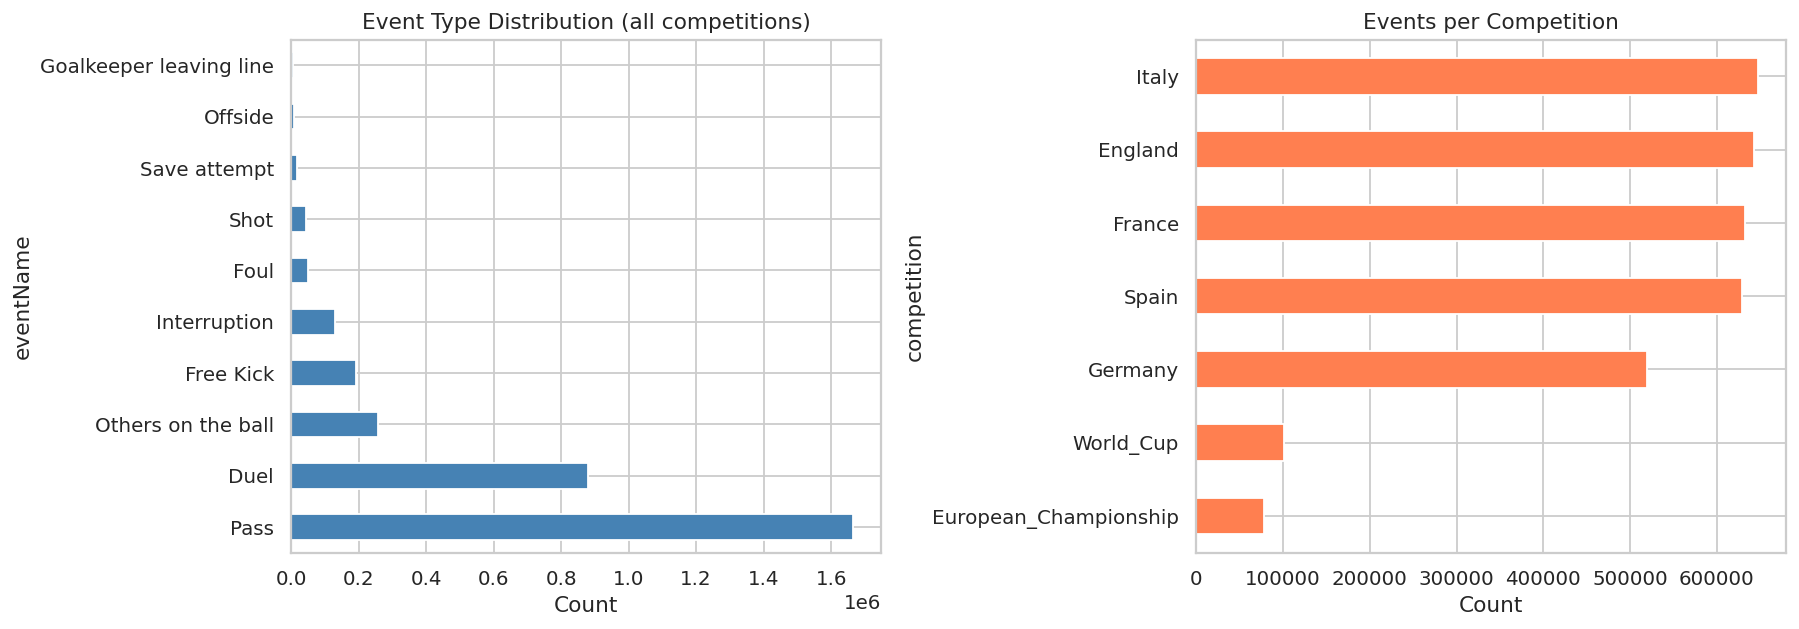

In [7]:
# ── Event type distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

events_df['eventName'].value_counts().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Event Type Distribution (all competitions)')
axes[0].set_xlabel('Count')

events_df.groupby('competition')['eventName'].count().sort_values().plot.barh(ax=axes[1], color='coral')
axes[1].set_title('Events per Competition')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig(OUT / 'eda_event_distribution.png', dpi=130)
plt.show()

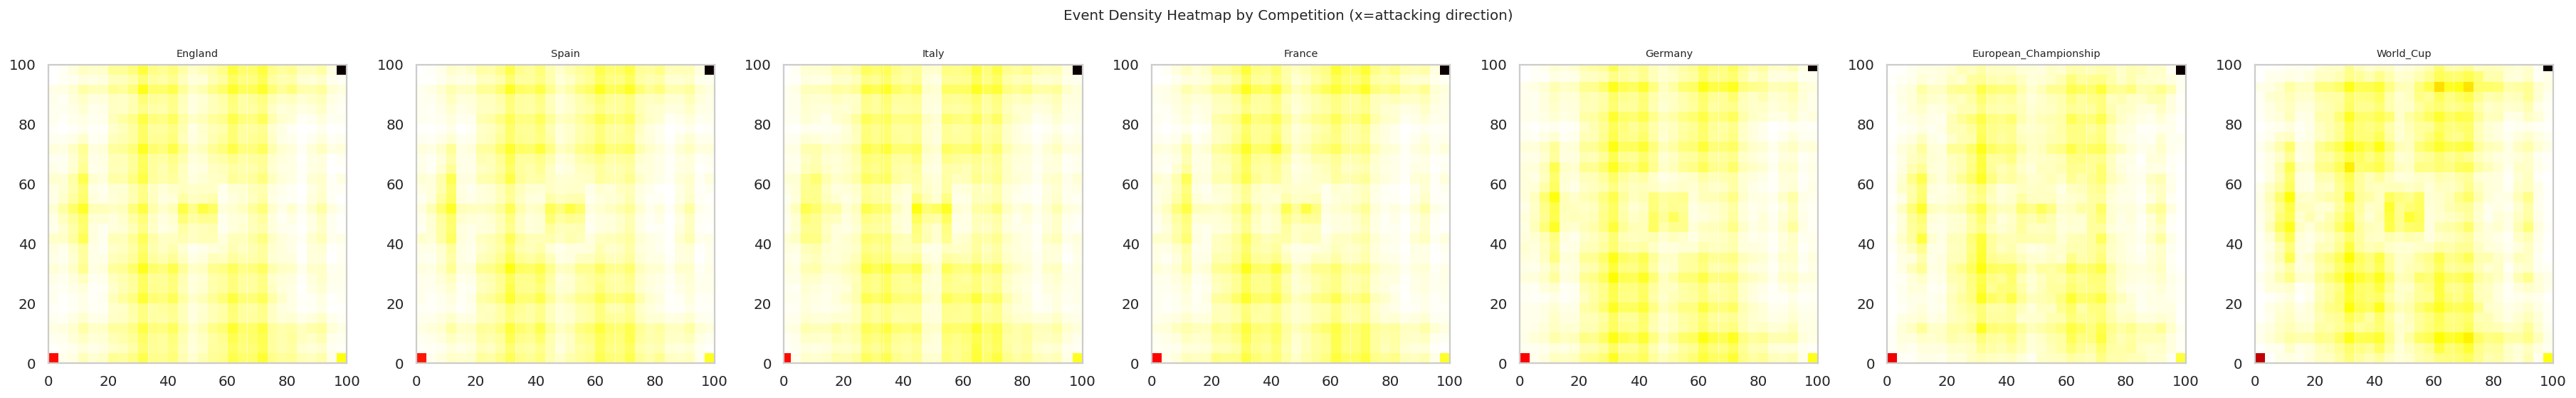

In [8]:
# ── Spatial heatmap — where events happen on the pitch ────────────────────────
fig, axes = plt.subplots(1, len(COMPETITIONS), figsize=(4*len(COMPETITIONS), 4))
if len(COMPETITIONS) == 1: axes = [axes]

for ax, comp in zip(axes, COMPETITIONS):
    sub = events_df[events_df['competition'] == comp]
    ax.hist2d(sub['pos_x'].dropna(), sub['pos_y'].dropna(),
              bins=30, cmap='hot_r', density=True)
    ax.set_title(comp, fontsize=8)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_aspect('equal')
    ax.axvline(33.3, color='white', lw=0.5, alpha=0.6)
    ax.axvline(66.6, color='white', lw=0.5, alpha=0.6)

plt.suptitle('Event Density Heatmap by Competition (x=attacking direction)', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'eda_spatial_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

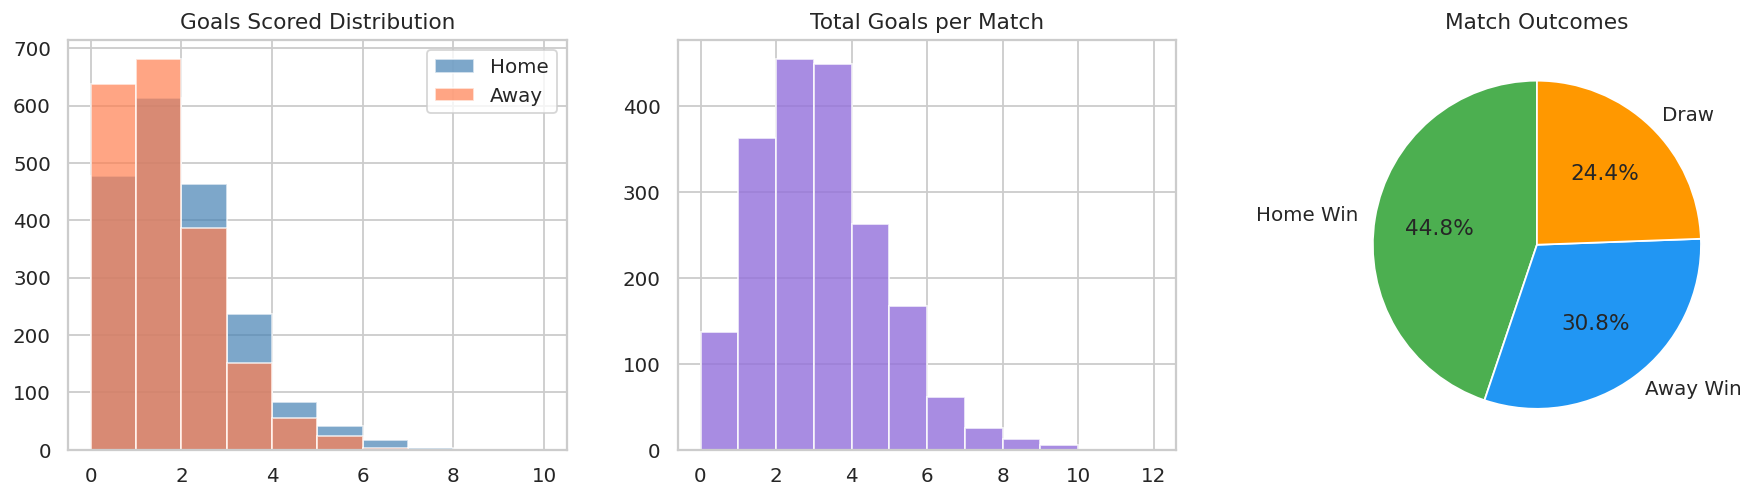

In [9]:
# ── Match outcomes distribution ───────────────────────────────────────────────
home_goals = matches_df['homeScore'].dropna()
away_goals = matches_df['awayScore'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(home_goals, bins=range(0, 11), alpha=0.7, color='steelblue', label='Home')
axes[0].hist(away_goals, bins=range(0, 11), alpha=0.7, color='coral', label='Away')
axes[0].set_title('Goals Scored Distribution')
axes[0].legend()

total_goals = home_goals + away_goals
axes[1].hist(total_goals.dropna(), bins=range(0, 13), color='mediumpurple', alpha=0.8)
axes[1].set_title('Total Goals per Match')

result = matches_df.copy()
result['result'] = result.apply(
    lambda r: 'Draw' if r['winner'] == 0
    else ('Home Win' if r['winner'] == r['homeTeamId'] else 'Away Win'), axis=1
)
result['result'].value_counts().plot.pie(ax=axes[2], autopct='%1.1f%%',
    colors=['#4CAF50','#2196F3','#FF9800'], startangle=90)
axes[2].set_ylabel('')
axes[2].set_title('Match Outcomes')

plt.tight_layout()
plt.savefig(OUT / 'eda_match_outcomes.png', dpi=130)
plt.show()

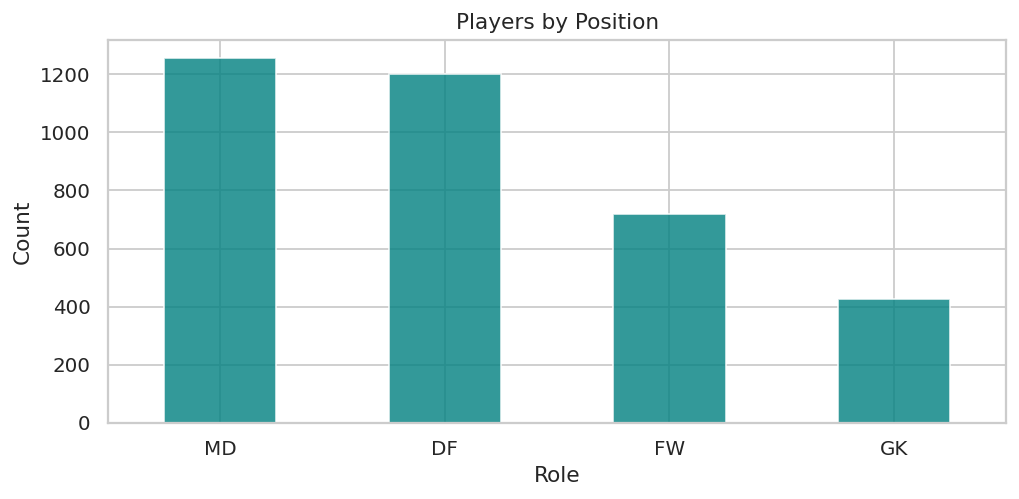

In [10]:
# ── Player role distribution ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
players_df['role'].value_counts().plot.bar(ax=ax, color='teal', alpha=0.8)
ax.set_title('Players by Position')
ax.set_xlabel('Role'); ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT / 'eda_player_roles.png', dpi=130)
plt.show()

---
## 3. Preprocess

Events after cleaning: 3,251,291  (dropped 3)


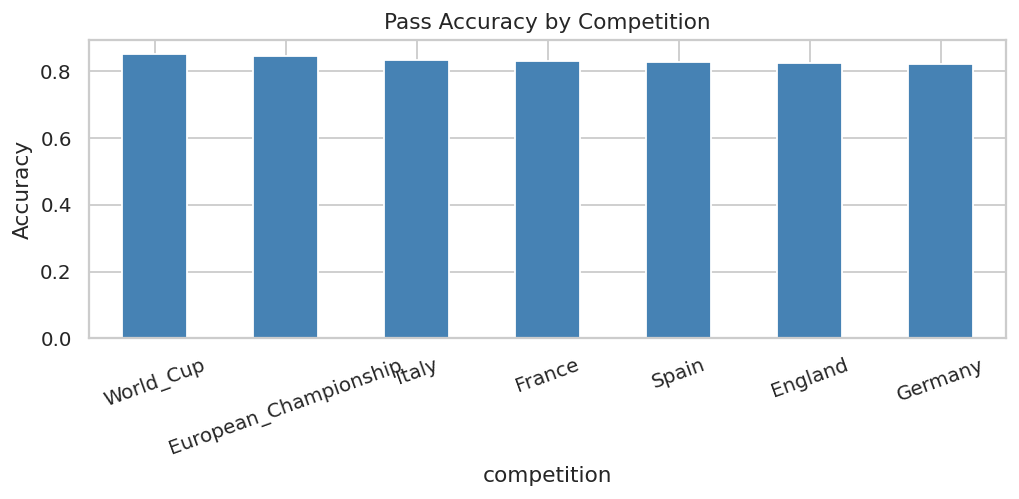

In [11]:
from src.data.preprocessor import preprocess, filter_passes

events_clean = preprocess(events_df, matches_df)
print(f'Events after cleaning: {len(events_clean):,}  (dropped {len(events_df)-len(events_clean):,})')

# Pass accuracy per competition
passes_all = filter_passes(events_clean, accurate_only=False)
acc = passes_all.groupby('competition')['accurate'].mean().sort_values(ascending=False)
acc.plot.bar(color='steelblue', figsize=(8, 4))
plt.title('Pass Accuracy by Competition'); plt.ylabel('Accuracy'); plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUT / 'eda_pass_accuracy.png', dpi=130)
plt.show()

---
## 4. Event Feature Extraction

In [12]:
from src.features.event_features import extract_event_features

event_feats = extract_event_features(events_clean)
print(f'Feature matrix: {event_feats.shape}')
event_feats.describe().round(3)

Feature matrix: (3882, 23)


,matchId,teamId,n_events,n_passes,n_shots,n_duels,pass_accuracy,shot_accuracy,duel_win_rate,avg_pos_x,...,pass_def_third,pass_mid_third,pass_att_third,cross_ratio,simple_pass_ratio,smart_pass_ratio,high_pass_ratio,long_ball_ratio,counter_rate,dangerous_rate
count,3882.000,3882.000,3882.000,3882.000,3882.000,3882.000,3882.000,3882.000,3882.000,3882.000,...,3882.000,3882.000,3882.000,3882.000,3882.000,3882.000,3882.000,3882.000,3882.000,3882.000
mean,2494852.981,3024.326,837.530,429.033,11.097,226.451,0.817,0.357,0.386,48.540,...,0.306,0.471,0.223,0.038,0.755,0.018,0.084,0.032,0.015,0.001
std,159688.003,2970.345,119.716,127.751,4.798,34.592,0.054,0.173,0.046,3.857,...,0.079,0.065,0.060,0.016,0.076,0.010,0.029,0.022,0.014,0.002
min,1694390.000,674.000,408.000,121.000,0.000,125.000,0.582,0.000,0.234,34.703,...,0.077,0.244,0.058,0.000,0.449,0.000,0.012,0.000,0.000,0.000
25%,2500089.000,1619.000,759.000,338.000,8.000,203.000,0.783,0.250,0.355,46.142,...,0.252,0.427,0.183,0.026,0.708,0.011,0.063,0.015,0.005,0.000
50%,2516834.000,2460.000,833.000,413.000,11.000,226.000,0.822,0.333,0.386,48.573,...,0.303,0.471,0.220,0.036,0.762,0.017,0.081,0.027,0.012,0.001
75%,2565822.000,3766.000,911.000,508.000,14.000,250.000,0.856,0.462,0.417,51.097,...,0.357,0.512,0.261,0.048,0.810,0.024,0.101,0.044,0.023,0.002
max,2576338.000,19830.000,1525.000,1078.000,39.000,384.000,0.943,1.000,0.561,62.459,...,0.639,0.726,0.497,0.119,0.930,0.077,0.230,0.139,0.130,0.019


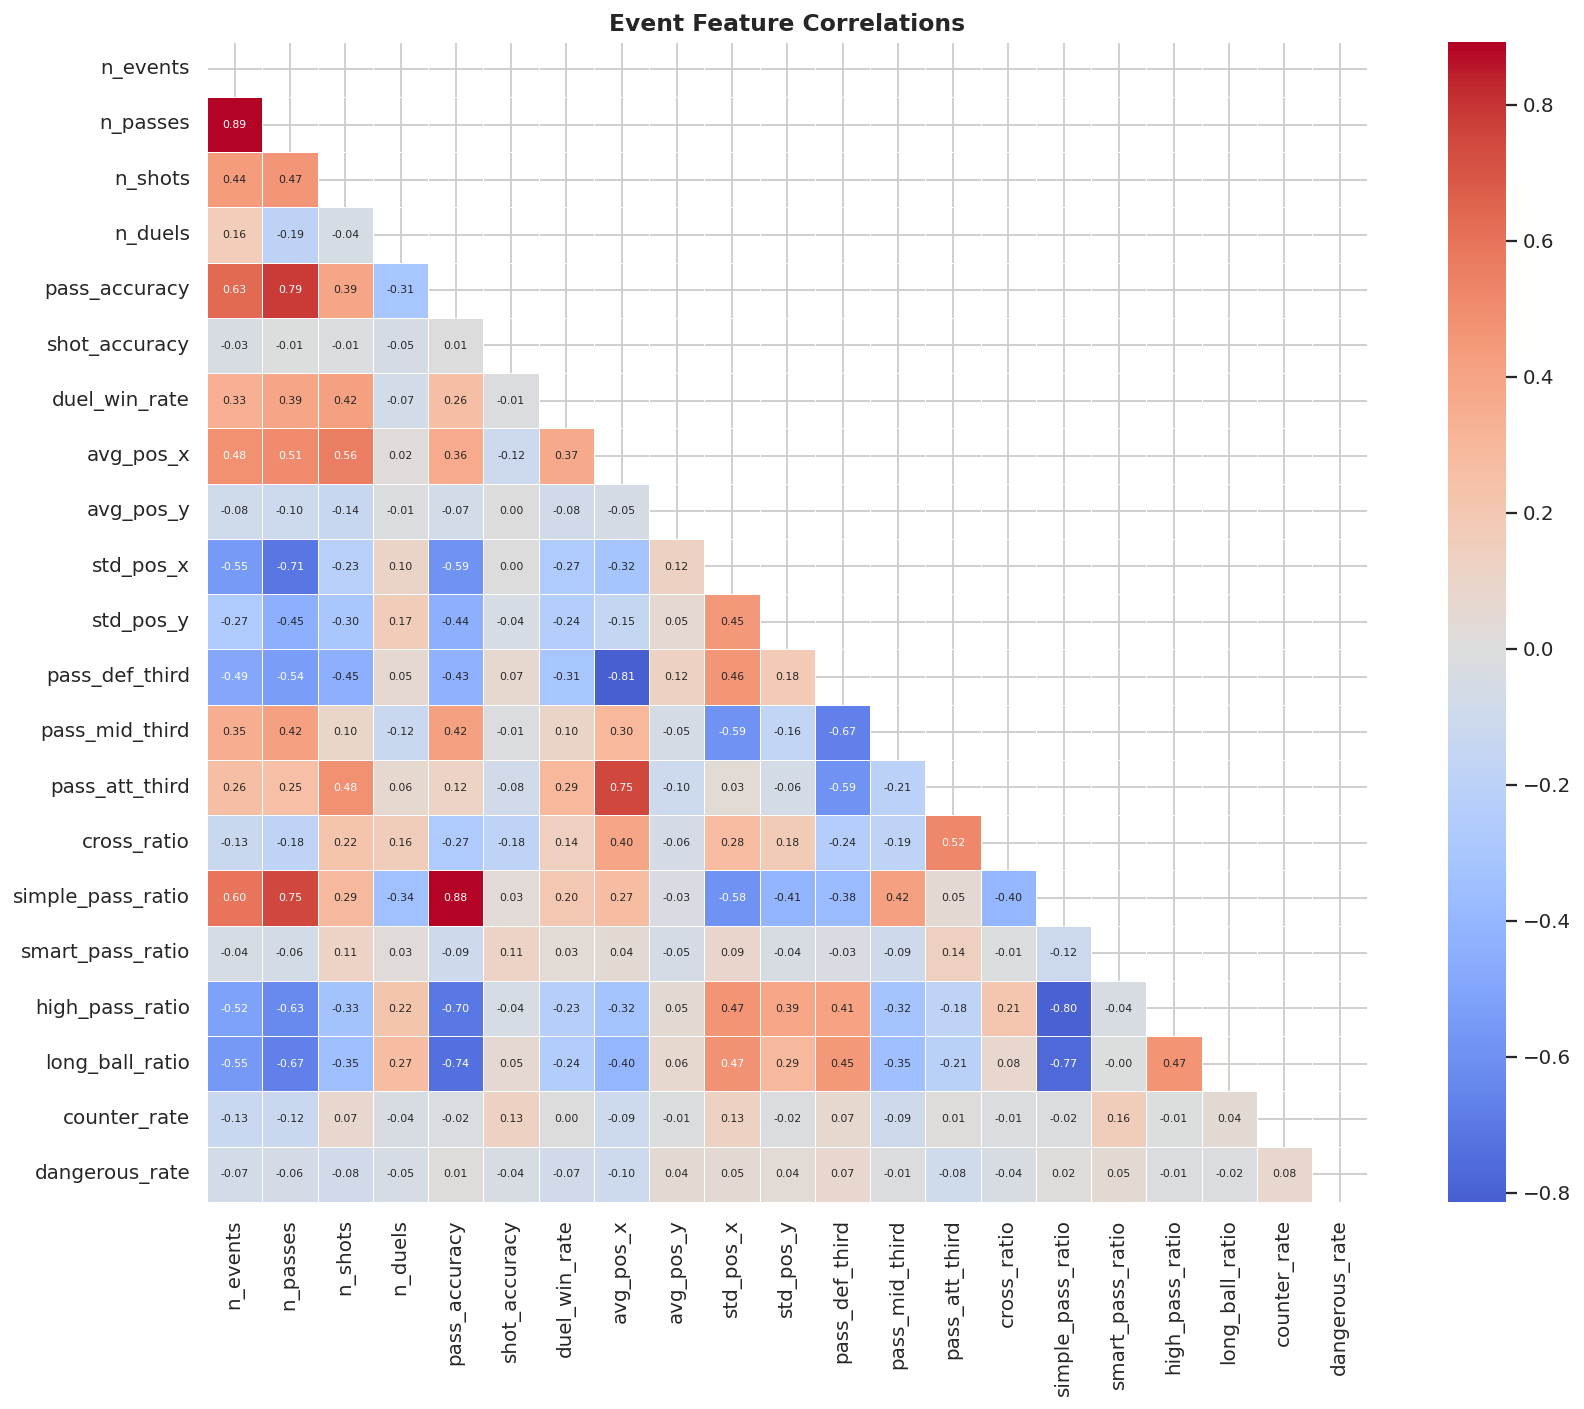

In [13]:
# ── Feature correlation heatmap ───────────────────────────────────────────────
feat_cols = [c for c in event_feats.columns if c not in {'matchId','teamId'}]
corr = event_feats[feat_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size':6},
            square=True, linewidths=0.3, ax=ax)
ax.set_title('Event Feature Correlations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'feature_correlation.png', dpi=130)
plt.show()

---
## 5. Passing Network Analysis

In [14]:
from src.network.builder import build_all_networks
from src.network.metrics import compute_network_metrics

passes      = filter_passes(events_clean, accurate_only=True)
networks    = build_all_networks(passes)
net_metrics = compute_network_metrics(networks)

print(f'Networks: {len(networks):,}   Metric rows: {len(net_metrics):,}')
net_metrics.describe().round(3)

Networks: 3,882   Metric rows: 3,882


,matchId,teamId,n_nodes,n_edges,density,clustering_coef,weighted_clustering,centralization,top_player_share,avg_shortest_path,diameter,reciprocity
count,3882.000,3882.000,3882.000,3882.000,3882.000,3882.000,3882.000,3882.000,3882.000,3882.000,3882.000,3882.000
mean,2494852.981,3024.326,13.644,106.909,0.621,0.841,0.186,0.524,0.211,1.368,2.097,0.797
std,159688.003,2970.345,0.604,13.006,0.073,0.049,0.050,0.100,0.058,0.222,0.466,0.063
min,1694390.000,674.000,11.000,47.000,0.301,0.557,0.056,0.182,0.095,0.000,0.000,0.447
25%,2500089.000,1619.000,13.000,99.000,0.571,0.816,0.151,0.451,0.170,1.330,2.000,0.761
50%,2516834.000,2460.000,14.000,107.000,0.621,0.849,0.182,0.516,0.202,1.385,2.000,0.804
75%,2565822.000,3766.000,14.000,116.000,0.670,0.874,0.216,0.593,0.243,1.451,2.000,0.841
max,2576338.000,19830.000,15.000,146.000,0.909,1.000,0.415,1.011,0.541,1.923,4.000,0.957


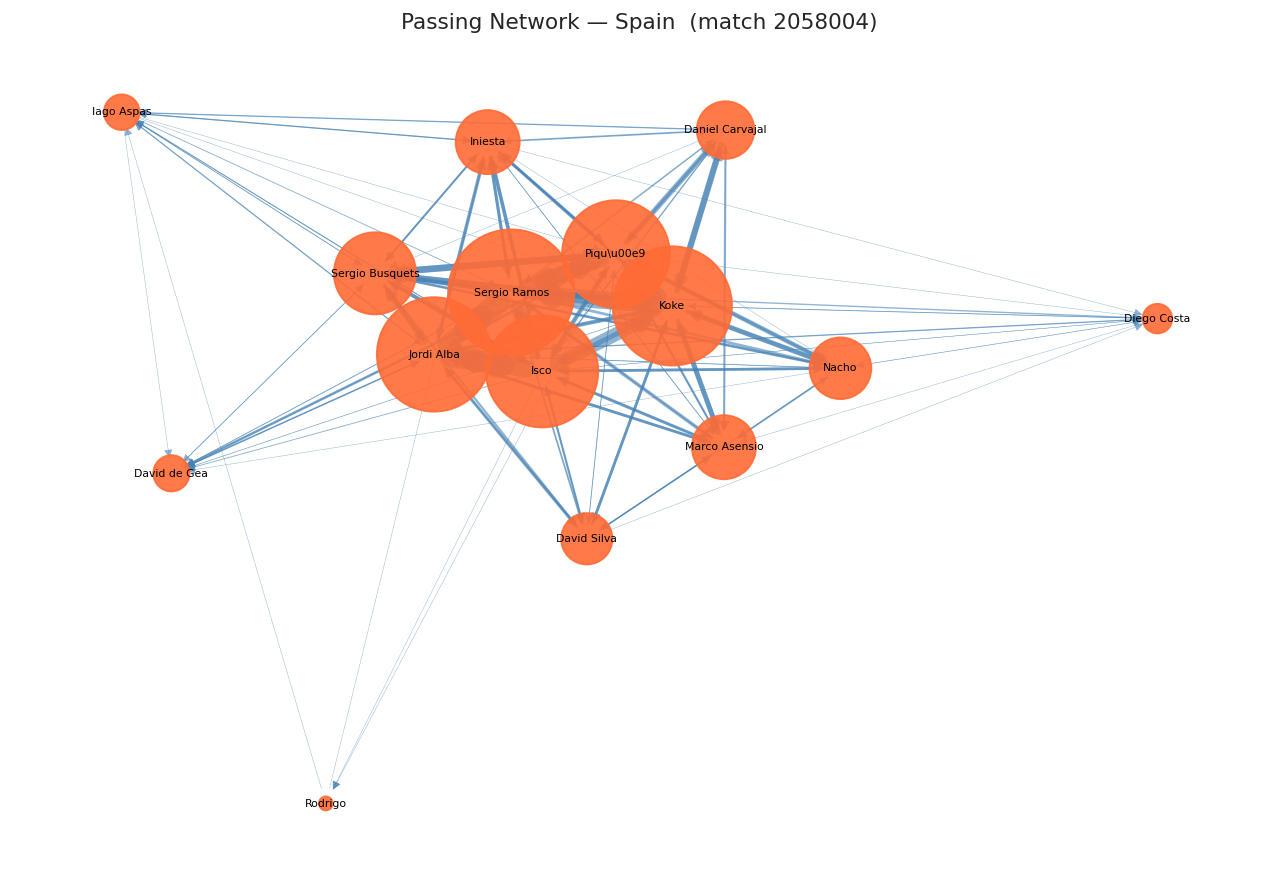

In [15]:
# ── Sample network visualisation (top team by pass volume in first match) ──────
top_key = passes.groupby(['matchId','teamId']).size().idxmax()
G = networks[top_key]
team_name = teams_df.set_index('teamId')['name'].get(int(top_key[1]), str(top_key[1]))

weights  = [G[u][v]['weight'] for u, v in G.edges()]
node_deg = dict(G.degree(weight='weight'))
node_sizes = [node_deg.get(n, 1) * 15 for n in G.nodes()]
labels   = {n: players_df.set_index('playerId')['shortName'].get(n, str(n)) for n in G.nodes()}

fig, ax = plt.subplots(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42, k=1.5)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#FF6B35', alpha=0.9, ax=ax)
nx.draw_networkx_edges(G, pos, width=[w*0.25 for w in weights],
                       edge_color='steelblue', alpha=0.6, arrows=True,
                       arrowsize=10, ax=ax)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=6, ax=ax)
ax.set_title(f'Passing Network — {team_name}  (match {top_key[0]})', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT / 'sample_passing_network.png', dpi=130)
plt.show()

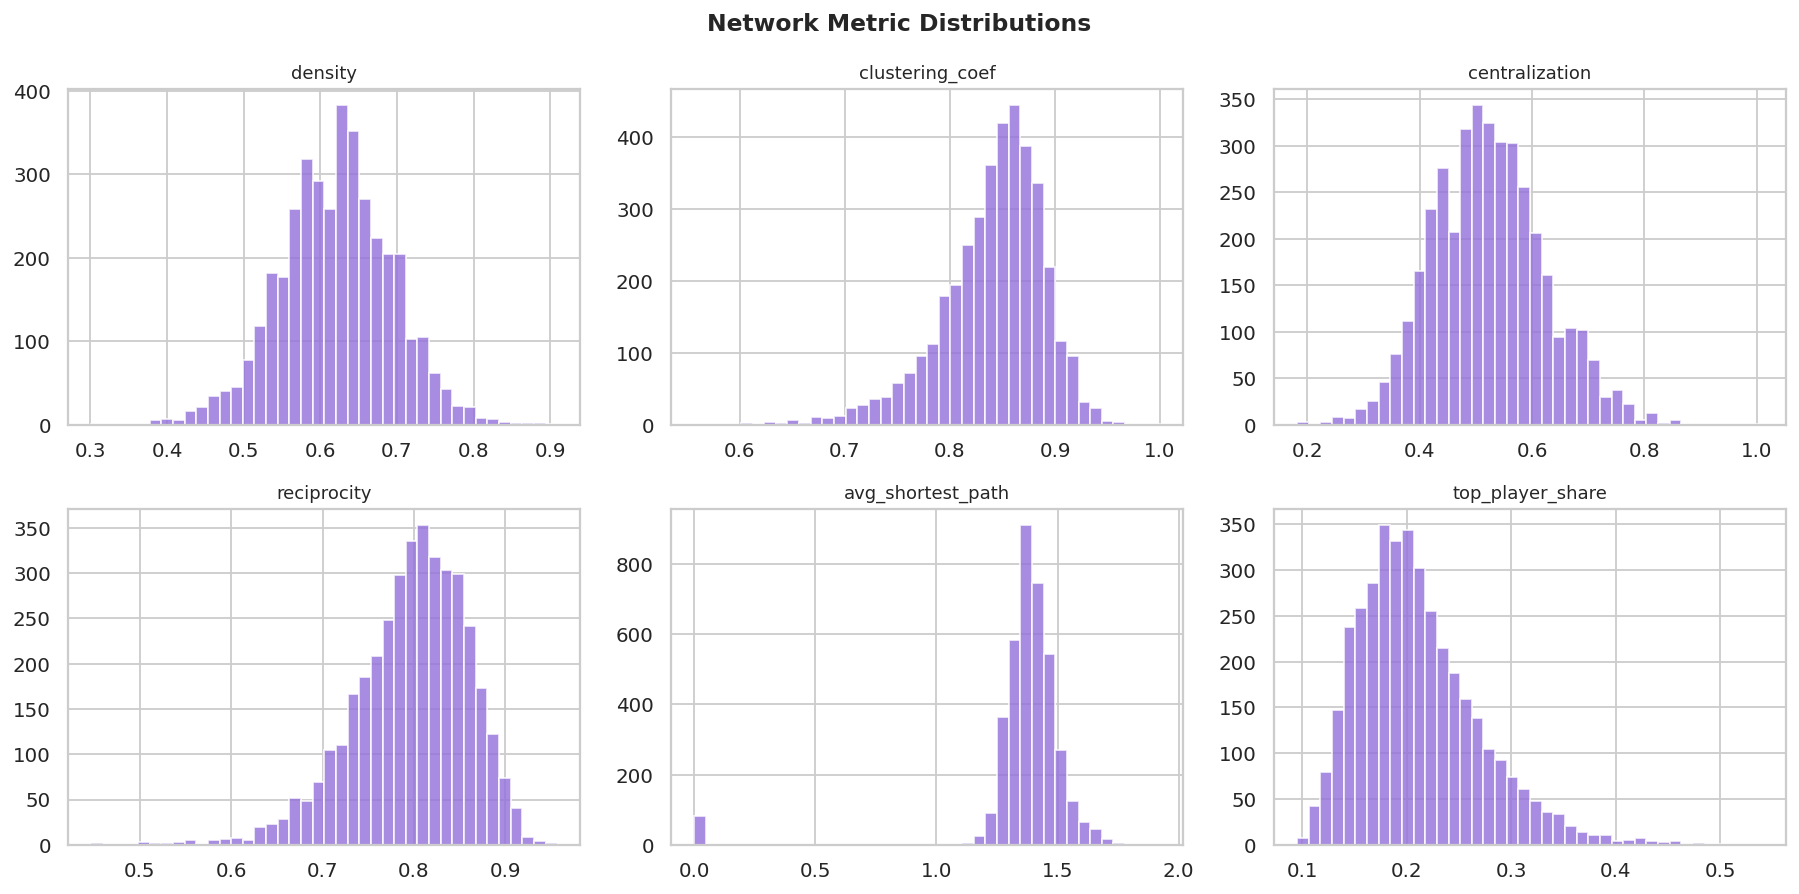

In [16]:
# ── Network metrics distribution ──────────────────────────────────────────────
net_plot_cols = ['density','clustering_coef','centralization',
                 'reciprocity','avg_shortest_path','top_player_share']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, net_plot_cols):
    net_metrics[col].dropna().hist(bins=40, ax=ax, color='mediumpurple', alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
plt.suptitle('Network Metric Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'network_metric_distributions.png', dpi=130)
plt.show()

---
## 6. Team Profile Aggregation

In [37]:
from src.features.aggregator import aggregate_team_profiles, build_fingerprint_matrix

combined = event_feats.merge(net_metrics, on=['matchId','teamId'], how='inner')
profiles = aggregate_team_profiles(combined, matches_df)
profiles = profiles.merge(teams_df[['teamId','name']], on='teamId', how='left')

print(f'Team profiles: {len(profiles)}')

X, y = build_fingerprint_matrix(profiles)
feature_cols = [c for c in X.columns if c not in {'teamId','competition', 'name'}]

Team profiles: 154


In [22]:
profiles.columns

Index(['teamId', 'competition', 'n_events', 'n_passes', 'n_shots', 'n_duels',
       'pass_accuracy', 'shot_accuracy', 'duel_win_rate', 'avg_pos_x',
       'avg_pos_y', 'std_pos_x', 'std_pos_y', 'pass_def_third',
       'pass_mid_third', 'pass_att_third', 'cross_ratio', 'simple_pass_ratio',
       'smart_pass_ratio', 'high_pass_ratio', 'long_ball_ratio',
       'counter_rate', 'dangerous_rate', 'n_nodes', 'n_edges', 'density',
       'clustering_coef', 'weighted_clustering', 'centralization',
       'top_player_share', 'avg_shortest_path', 'diameter', 'reciprocity',
       'win_rate', 'draw', 'loss', 'points_per_match', 'goalDiff', 'goalsFor',
       'goalsAgainst', 'name'],
      dtype='object')

In [25]:
y

,teamId,competition,goalsFor,goalsAgainst,loss,draw,win_rate,goalDiff,points_per_match
0,674,Spain,1.710526,1.000000,0.236842,0.184211,0.578947,0.710526,1.921053
1,675,Spain,2.473684,1.157895,0.157895,0.263158,0.578947,1.315789,2.000000
2,676,Spain,2.605263,0.763158,0.026316,0.236842,0.736842,1.842105,2.447368
3,677,Spain,1.000000,2.000000,0.552632,0.289474,0.157895,-1.000000,0.763158
4,678,Spain,1.078947,1.289474,0.394737,0.342105,0.263158,-0.210526,1.131579
...,...,...,...,...,...,...,...,...,...
149,16871,World_Cup,0.666667,1.666667,0.666667,0.333333,0.000000,-1.000000,0.333333
150,17322,World_Cup,0.666667,1.333333,0.666667,0.000000,0.333333,-0.666667,1.000000
151,17929,World_Cup,0.666667,3.666667,1.000000,0.000000,0.000000,-3.000000,0.000000
152,19314,World_Cup,1.333333,1.333333,0.333333,0.333333,0.333333,0.000000,1.333333


In [27]:
top_teams = (
    profiles.merge(y[['teamId','competition','win_rate','points_per_match','goalDiff']],
                   on=['teamId','competition'], how='left', suffixes=('_profiles', '_y'))
    .sort_values('win_rate_y', ascending=False)
    .groupby('competition').head(3)[['competition','name','win_rate_y','points_per_match_y','goalDiff_y',
                                      'pass_accuracy','density','centralization']]
    .round(3)
)
print('Top 3 teams per competition by win rate')
display(top_teams)

Top 3 teams per competition by win rate


,competition,name,win_rate_y,points_per_match_y,goalDiff_y,pass_accuracy,density,centralization
121,World_Cup,Croatia,0.857,2.571,0.571,0.826,0.609,0.607
107,World_Cup,Belgium,0.857,2.571,1.429,0.878,0.659,0.499
104,World_Cup,France,0.857,2.714,1.143,0.842,0.582,0.531
30,England,Manchester City,0.842,2.632,2.079,0.896,0.720,0.465
44,Germany,Bayern M\u00fcnchen,0.794,2.471,1.882,0.878,0.697,0.494
65,Italy,Juventus,0.789,2.500,1.632,0.880,0.663,0.519
85,France,PSG,0.763,2.447,2.079,0.892,0.687,0.506
2,Spain,Barcelona,0.737,2.447,1.842,0.883,0.687,0.466
76,Italy,Napoli,0.737,2.395,1.263,0.879,0.685,0.497
103,European_Championship,France,0.714,2.286,1.286,0.862,0.634,0.529


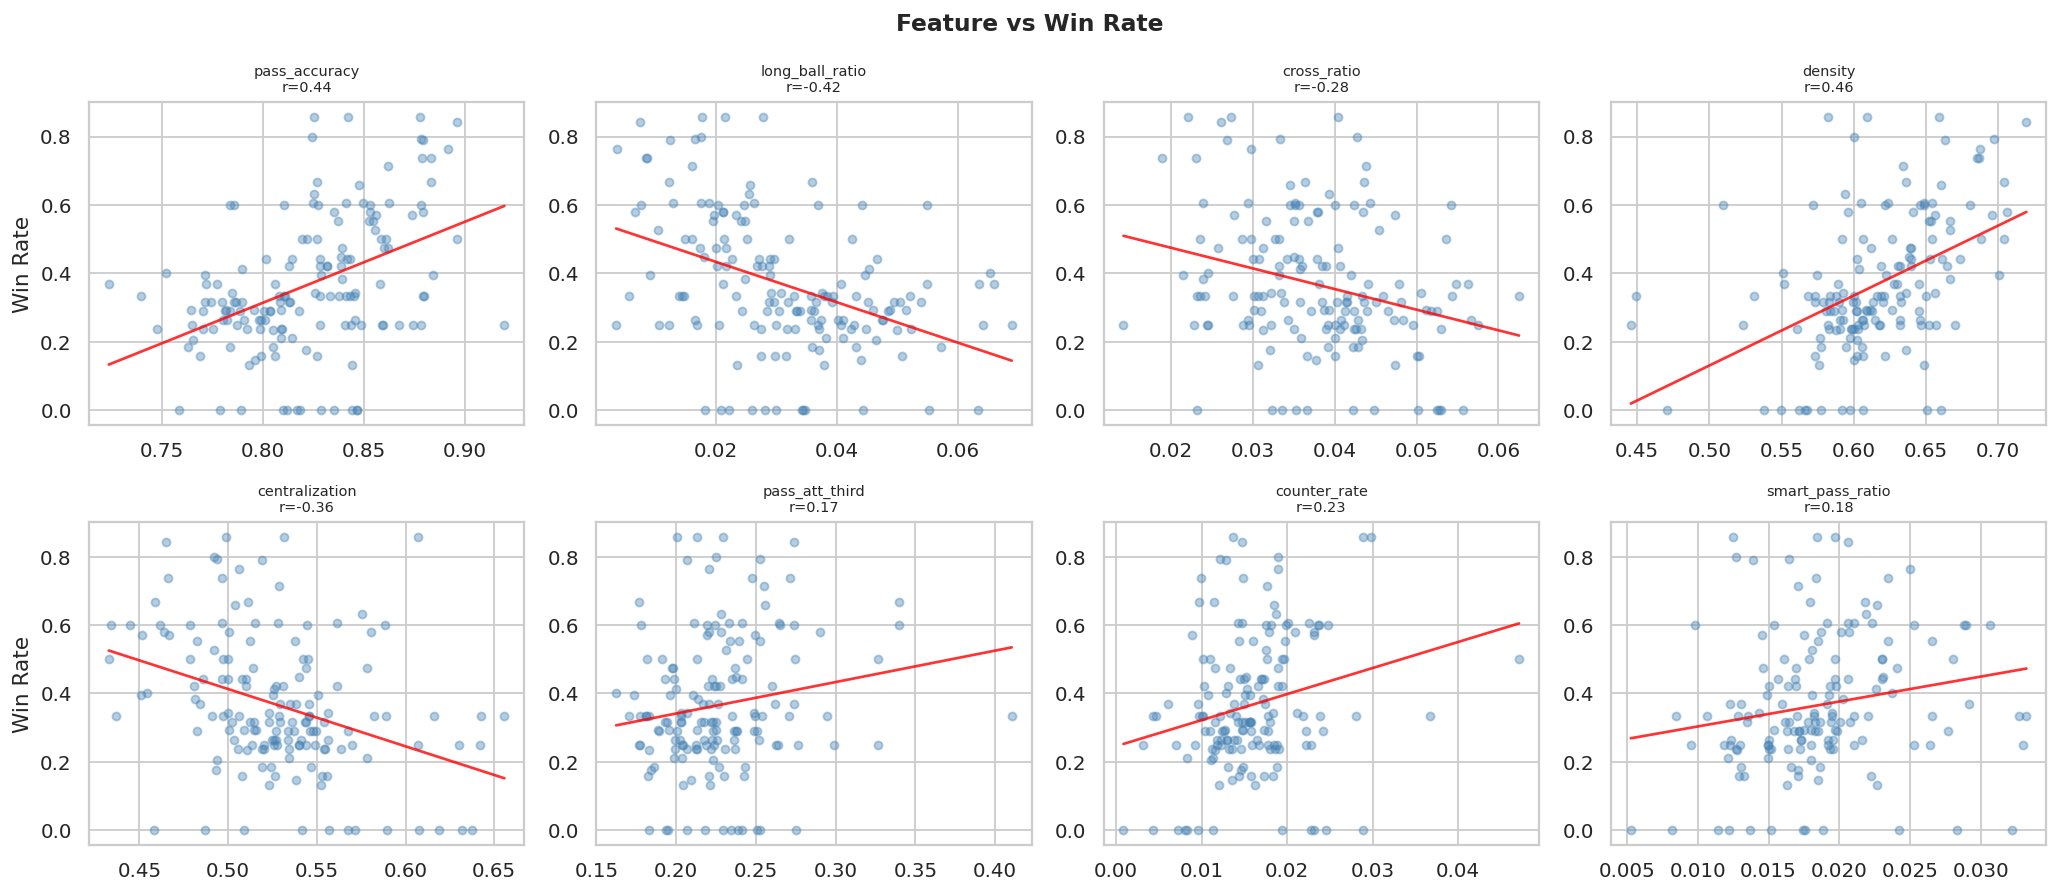

In [30]:
# ── Feature vs win rate scatter grid ─────────────────────────────────────────
full_profiles = profiles.merge(
    y[['teamId','competition','win_rate','points_per_match','goalDiff']],
    on=['teamId','competition'], how='left', suffixes=('_profiles', '_y')
)

key_features = ['pass_accuracy','long_ball_ratio','cross_ratio',
                'density','centralization','pass_att_third','counter_rate','smart_pass_ratio']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, feat in zip(axes.flat, key_features):
    ax.scatter(full_profiles[feat], full_profiles['win_rate_y'],
               alpha=0.4, s=20, color='steelblue')
    # trend line
    valid = full_profiles[[feat,'win_rate_y']].dropna()
    if len(valid) > 5:
        z = np.polyfit(valid[feat], valid['win_rate_y'], 1)
        p = np.poly1d(z)
        xs = np.linspace(valid[feat].min(), valid[feat].max(), 100)
        ax.plot(xs, p(xs), color='red', lw=1.5, alpha=0.8)
        corr = valid[feat].corr(valid['win_rate_y'])
        ax.set_title(f'{feat}\nr={corr:.2f}', fontsize=8)
    ax.set_xlabel(''); ax.set_ylabel('Win Rate' if ax in axes[:,0] else '')

plt.suptitle('Feature vs Win Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'feature_vs_win_rate.png', dpi=130)
plt.show()

---
## 7. PCA Analysis

In [35]:
X_raw

array([[810.2105263157895, 413.7894736842105, 11.0, ...,
        2.0789473684210527, 0.7969533020127393, 'Valencia'],
       [947.5, 581.078947368421, 16.605263157894736, ...,
        2.0526315789473686, 0.8698542047655797, 'Real Madrid'],
       [968.1578947368421, 612.1052631578947, 13.210526315789474, ...,
        2.0, 0.8514219170719708, 'Barcelona'],
       ...,
       [600.6666666666666, 318.0, 6.666666666666667, ..., 2.0,
        0.7775244925401806, 'Panama'],
       [654.6666666666666, 312.3333333333333, 8.0, ..., 2.0,
        0.757967939651108, 'Senegal'],
       [818.7105263157895, 418.7368421052632, 11.289473684210526, ...,
        2.0789473684210527, 0.7933109589810132, 'Monaco']], dtype=object)

In [36]:
feature_cols

['n_events',
 'n_passes',
 'n_shots',
 'n_duels',
 'pass_accuracy',
 'shot_accuracy',
 'duel_win_rate',
 'avg_pos_x',
 'avg_pos_y',
 'std_pos_x',
 'std_pos_y',
 'pass_def_third',
 'pass_mid_third',
 'pass_att_third',
 'cross_ratio',
 'simple_pass_ratio',
 'smart_pass_ratio',
 'high_pass_ratio',
 'long_ball_ratio',
 'counter_rate',
 'dangerous_rate',
 'n_nodes',
 'n_edges',
 'density',
 'clustering_coef',
 'weighted_clustering',
 'centralization',
 'top_player_share',
 'avg_shortest_path',
 'diameter',
 'reciprocity',
 'name']

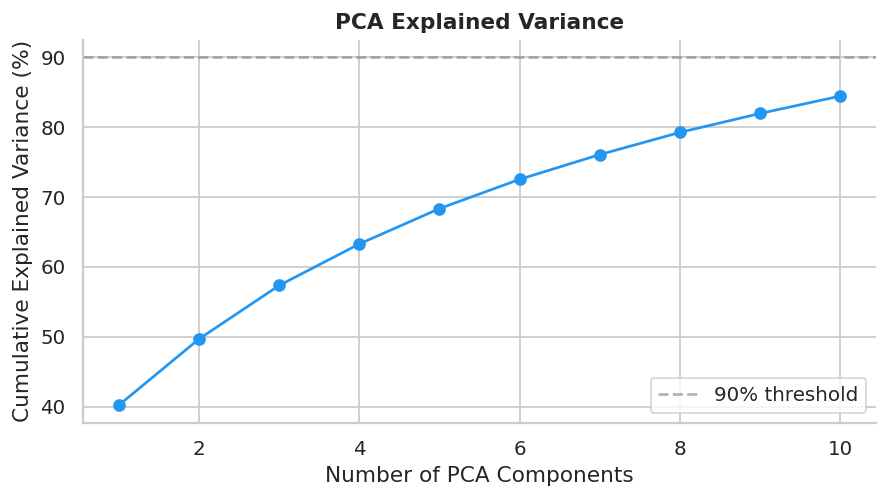

In [38]:
from src.clustering.fingerprints import scale_features, run_pca, find_optimal_clusters
from src.visualization.plots import plot_pca_variance, plot_silhouette_curve

X_raw            = full_profiles[feature_cols].fillna(0).values
X_scaled, scaler = scale_features(X_raw)
X_pca, pca       = run_pca(X_scaled, n_components=min(10, len(feature_cols)))

plot_pca_variance(np.cumsum(pca.explained_variance_ratio_))
plt.savefig(OUT / 'pca_variance.png', dpi=130)
plt.show()

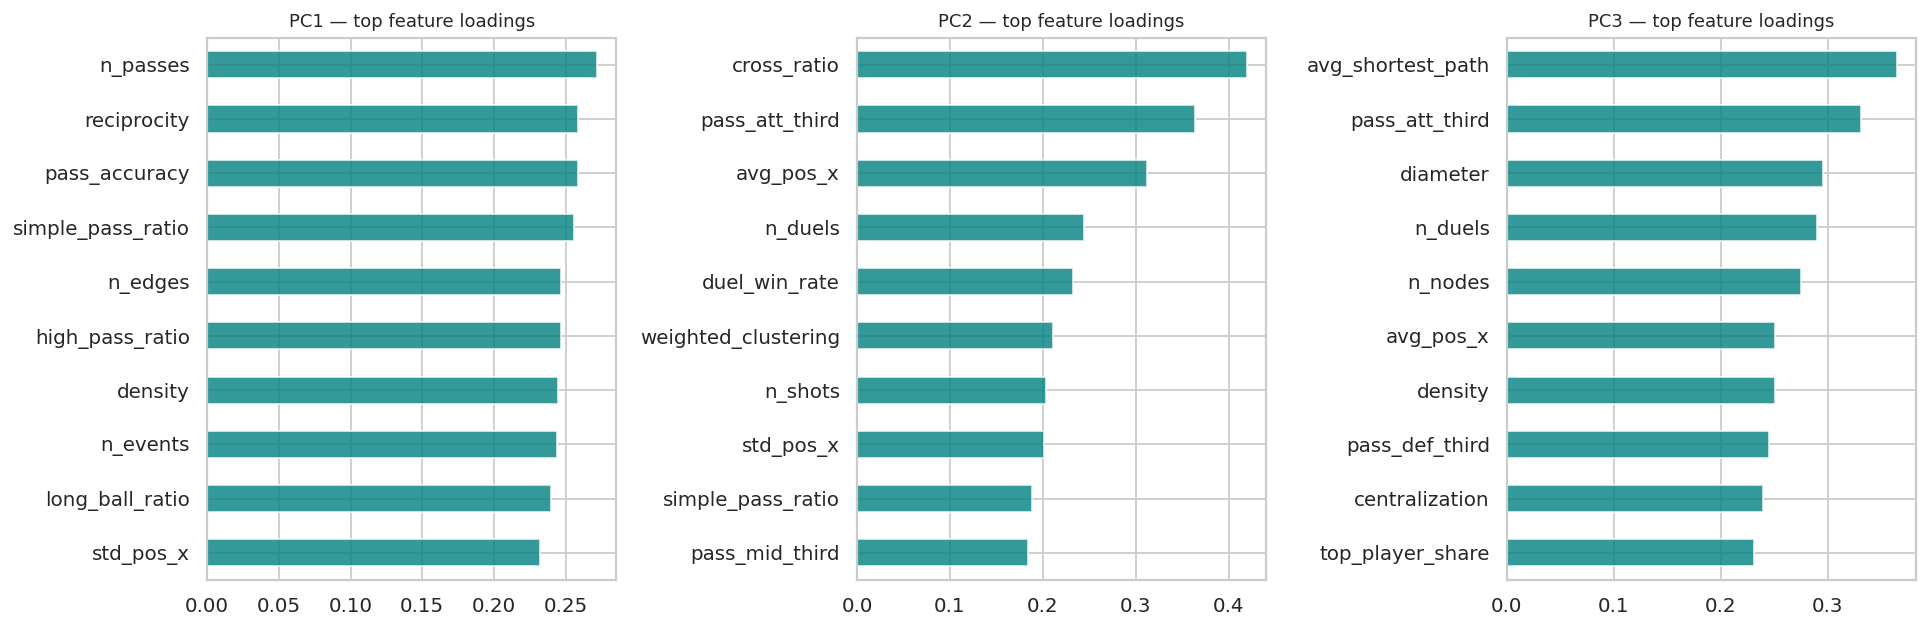

In [39]:
# ── Top feature loadings for each PC ─────────────────────────────────────────
n_show = 3
loading_df = pd.DataFrame(pca.components_[:n_show].T,
                           index=feature_cols,
                           columns=[f'PC{i+1}' for i in range(n_show)])

fig, axes = plt.subplots(1, n_show, figsize=(5*n_show, 5))
for ax, pc in zip(axes, loading_df.columns):
    loading_df[pc].abs().sort_values(ascending=True).tail(10).plot.barh(ax=ax, color='teal', alpha=0.8)
    ax.set_title(f'{pc} — top feature loadings', fontsize=10)
plt.tight_layout()
plt.savefig(OUT / 'pca_loadings.png', dpi=130)
plt.show()

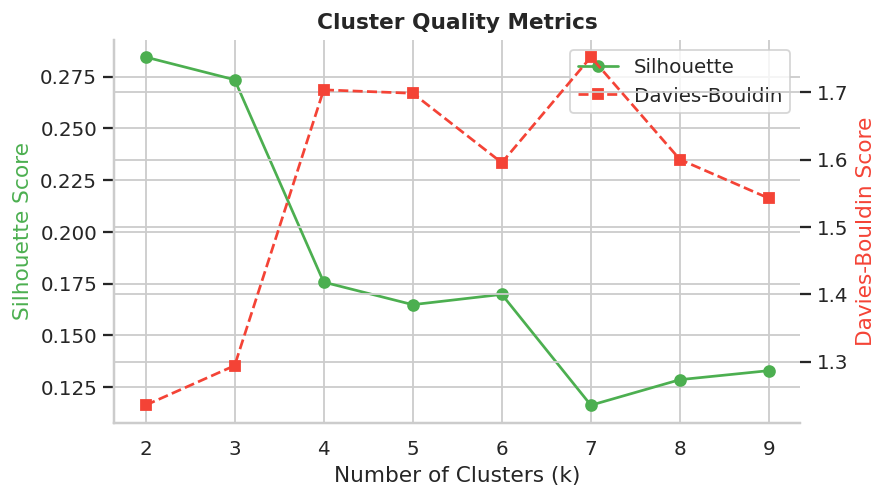

Best k by silhouette: 2  (configured: 5)
 k  silhouette  davies_bouldin
 2    0.284502        1.235257
 3    0.273538        1.294089
 4    0.175738        1.703834
 5    0.164853        1.698729
 6    0.169808        1.595593
 7    0.116265        1.752557
 8    0.128617        1.600300
 9    0.132980        1.542566


In [40]:
# ── Optimal cluster count ─────────────────────────────────────────────────────
eval_df = find_optimal_clusters(X_pca, k_range=range(2, 10))
plot_silhouette_curve(eval_df)
plt.savefig(OUT / 'cluster_quality.png', dpi=130)
plt.show()

best_k = eval_df.loc[eval_df['silhouette'].idxmax(), 'k']
print(f'Best k by silhouette: {best_k}  (configured: {N_CLUSTERS})')
print(eval_df.to_string(index=False))

---
## 8. Tactical Fingerprints

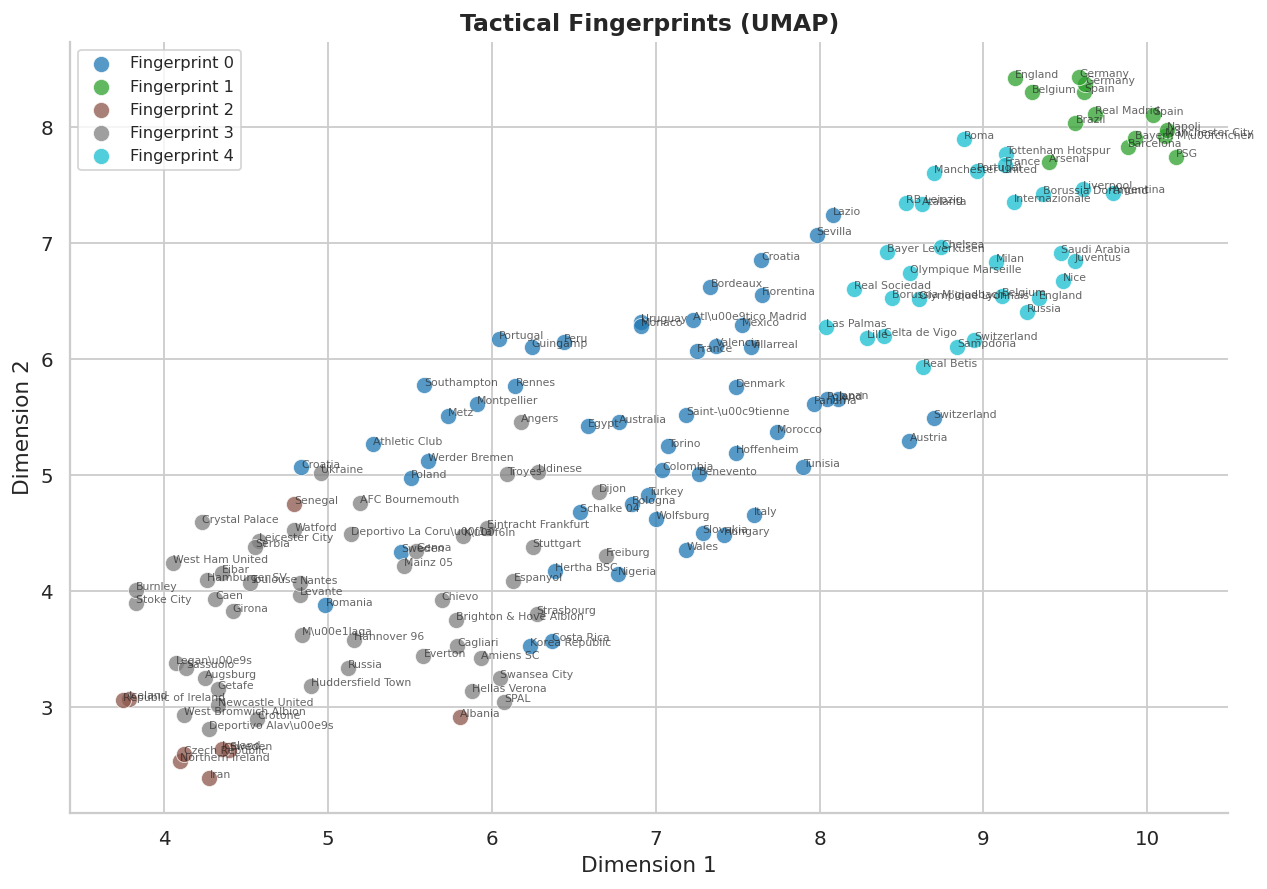

In [41]:
from src.clustering.fingerprints import build_fingerprint_report
from src.visualization.plots import (
    plot_cluster_scatter, plot_fingerprint_radar, plot_outcome_by_fingerprint
)

result   = build_fingerprint_report(
    profiles=full_profiles,
    feature_cols=feature_cols,
    n_clusters=N_CLUSTERS,
    use_umap=True,
)
labelled = result['profiles_labelled']
labelled = labelled.merge(teams_df[['teamId','name']], on='teamId', how='left')

plot_cluster_scatter(labelled, teams_df=teams_df, title='Tactical Fingerprints (UMAP)')
plt.savefig(OUT / 'fingerprint_scatter.png', dpi=130)
plt.show()

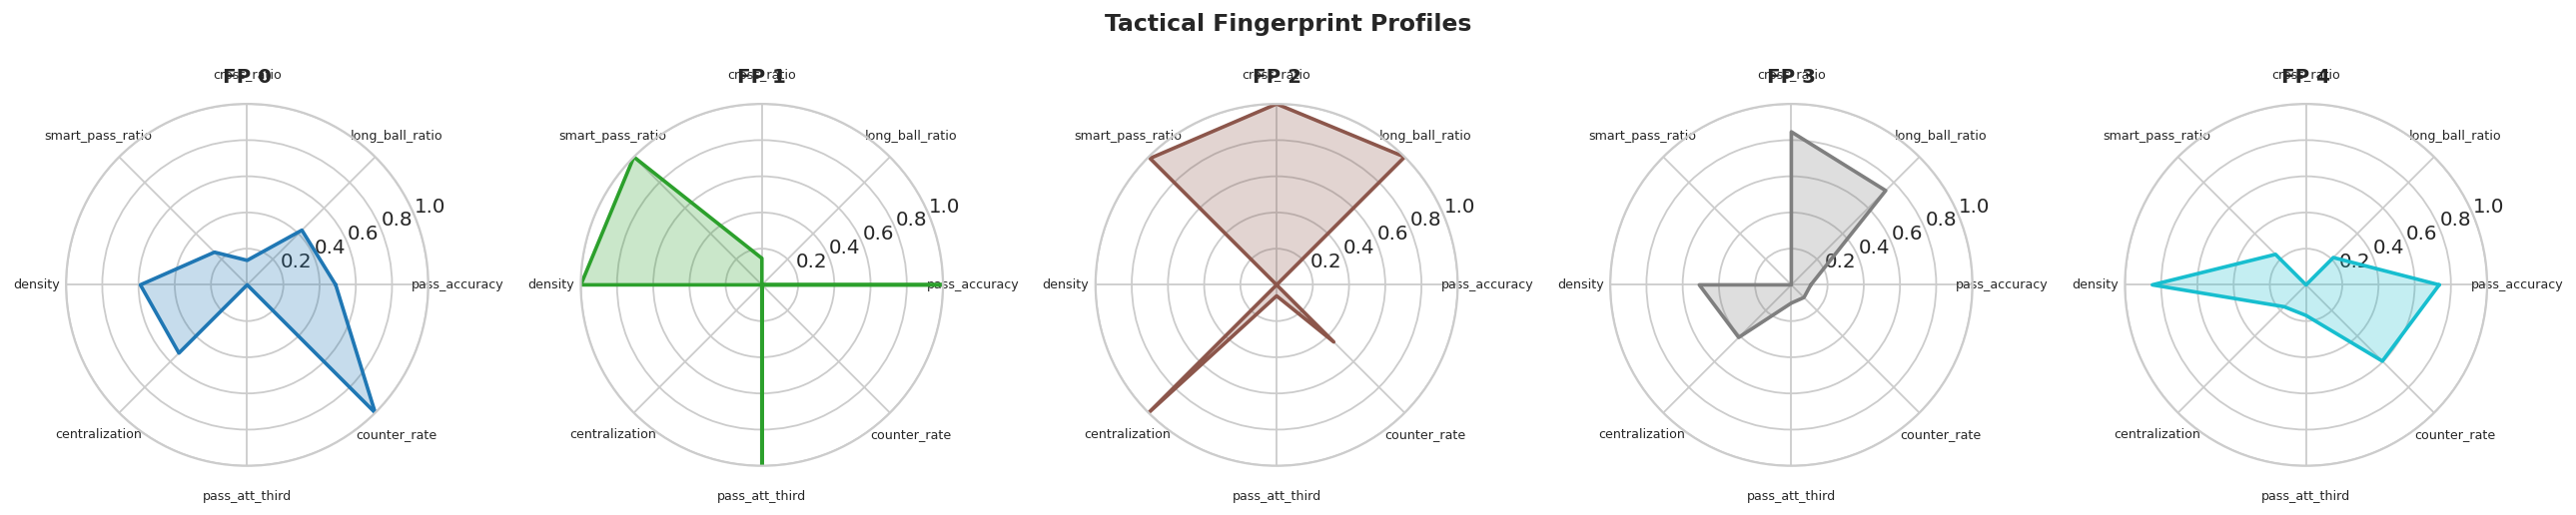

In [42]:
# ── Radar chart — fingerprint style profiles ──────────────────────────────────
radar_features = ['pass_accuracy','long_ball_ratio','cross_ratio','smart_pass_ratio',
                  'density','centralization','pass_att_third','counter_rate']
plot_fingerprint_radar(labelled, feature_cols=radar_features)
plt.savefig(OUT / 'fingerprint_radar.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 9. Fingerprints vs Match Outcomes

In [45]:
labelled

,teamId,competition,n_events,n_passes,n_shots,n_duels,pass_accuracy,shot_accuracy,duel_win_rate,avg_pos_x,...,goalsFor,goalsAgainst,name_x,win_rate_y,points_per_match_y,goalDiff_y,fingerprint,embed_x,embed_y,name_y
0,674,Spain,810.210526,413.789474,11.000000,224.631579,0.835443,0.391434,0.394563,48.026460,...,1.710526,1.000000,Valencia,0.578947,1.921053,0.710526,0,7.368587,6.113252,Valencia
1,675,Spain,947.500000,581.078947,16.605263,206.842105,0.879185,0.421921,0.427308,52.202797,...,2.473684,1.157895,Real Madrid,0.578947,2.000000,1.315789,1,9.680804,8.118134,Real Madrid
2,676,Spain,968.157895,612.105263,13.210526,202.789474,0.883462,0.485128,0.428679,51.206289,...,2.605263,0.763158,Barcelona,0.736842,2.447368,1.842105,1,9.879944,7.832149,Barcelona
3,677,Spain,797.815789,382.605263,10.657895,221.421053,0.799323,0.333401,0.386356,48.622159,...,1.000000,2.000000,Deportivo La Coru\u00f1a,0.157895,0.763158,-1.000000,3,5.140182,4.488888,Deportivo La Coru\u00f1a
4,678,Spain,803.842105,395.315789,9.921053,229.631579,0.799027,0.379532,0.393521,49.712476,...,1.078947,1.289474,Athletic Club,0.263158,1.131579,-0.210526,0,5.277513,5.264870,Athletic Club
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,16871,World_Cup,701.000000,341.333333,8.666667,215.333333,0.810199,0.253846,0.368899,46.626729,...,0.666667,1.666667,Costa Rica,0.000000,0.333333,-1.000000,0,6.368026,3.568398,Costa Rica
150,17322,World_Cup,752.000000,360.333333,10.000000,234.000000,0.828541,0.194613,0.400100,50.528019,...,0.666667,1.333333,Serbia,0.333333,1.000000,-0.666667,3,4.554238,4.383411,Serbia
151,17929,World_Cup,600.666667,318.000000,6.666667,159.333333,0.835201,0.301587,0.369571,47.743419,...,0.666667,3.666667,Panama,0.000000,0.000000,-3.000000,0,7.963147,5.615585,Panama
152,19314,World_Cup,654.666667,312.333333,8.000000,200.000000,0.810392,0.489683,0.401795,50.162636,...,1.333333,1.333333,Senegal,0.333333,1.333333,0.000000,2,4.793671,4.751745,Senegal


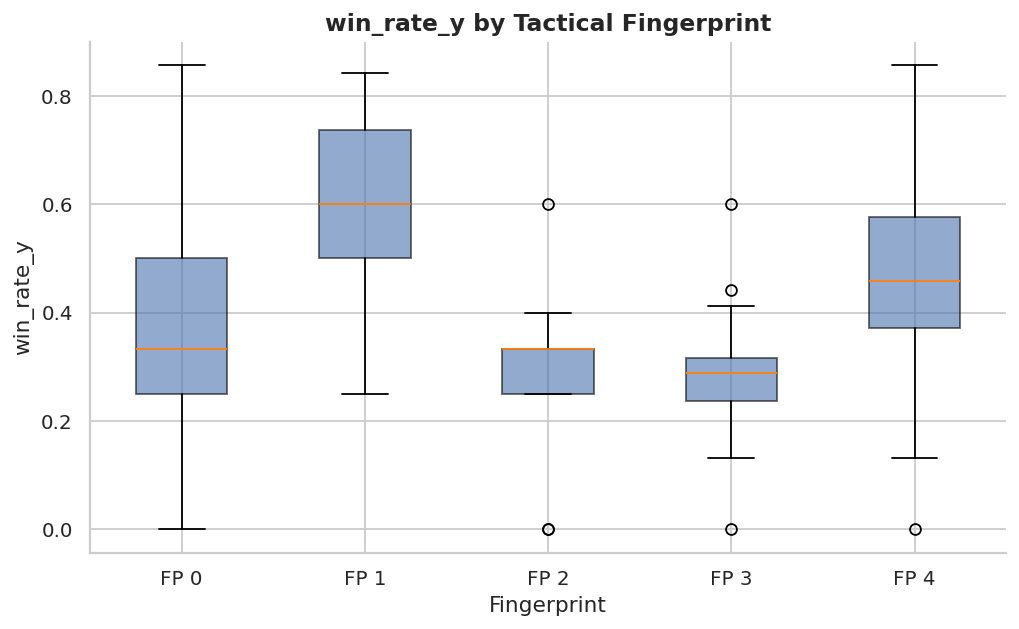

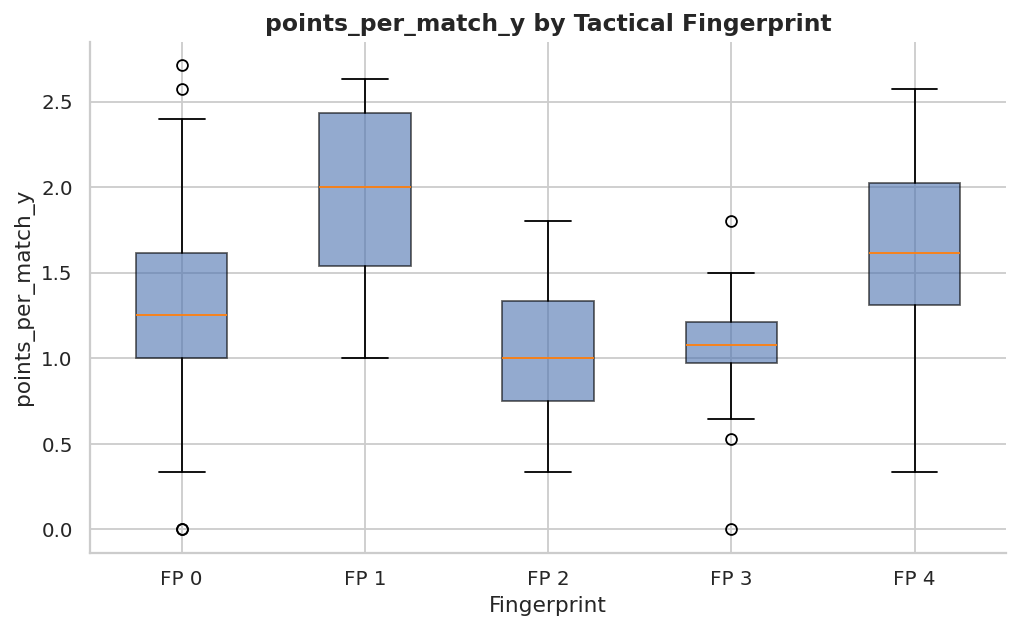

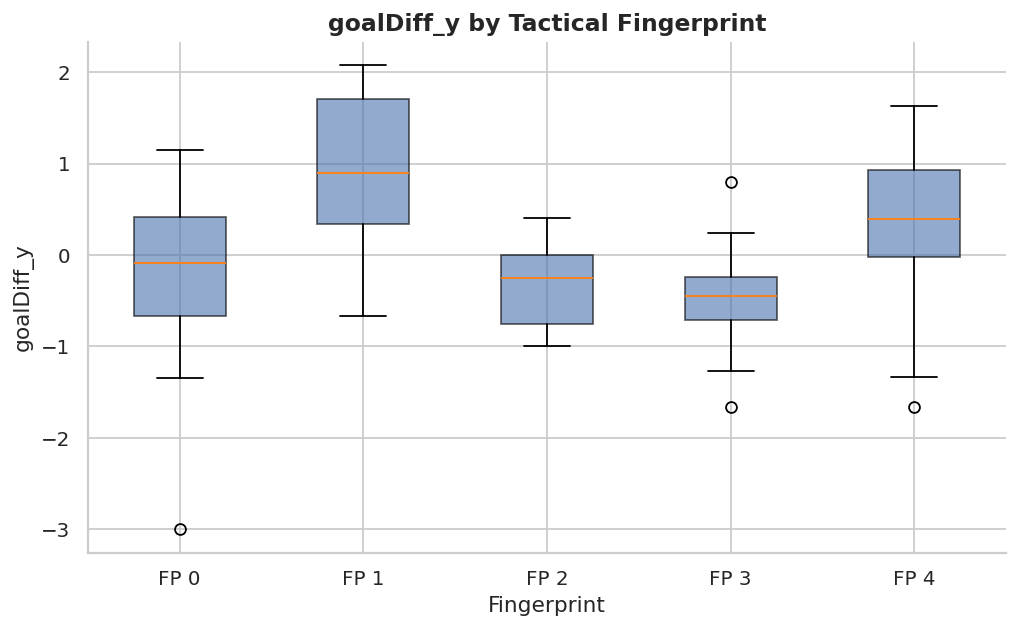

In [48]:
for metric in ['win_rate_y', 'points_per_match_y', 'goalDiff_y']:
    plot_outcome_by_fingerprint(labelled, metric=metric)
    plt.savefig(OUT / f'{metric}_by_fp.png', dpi=130)
    plt.show()

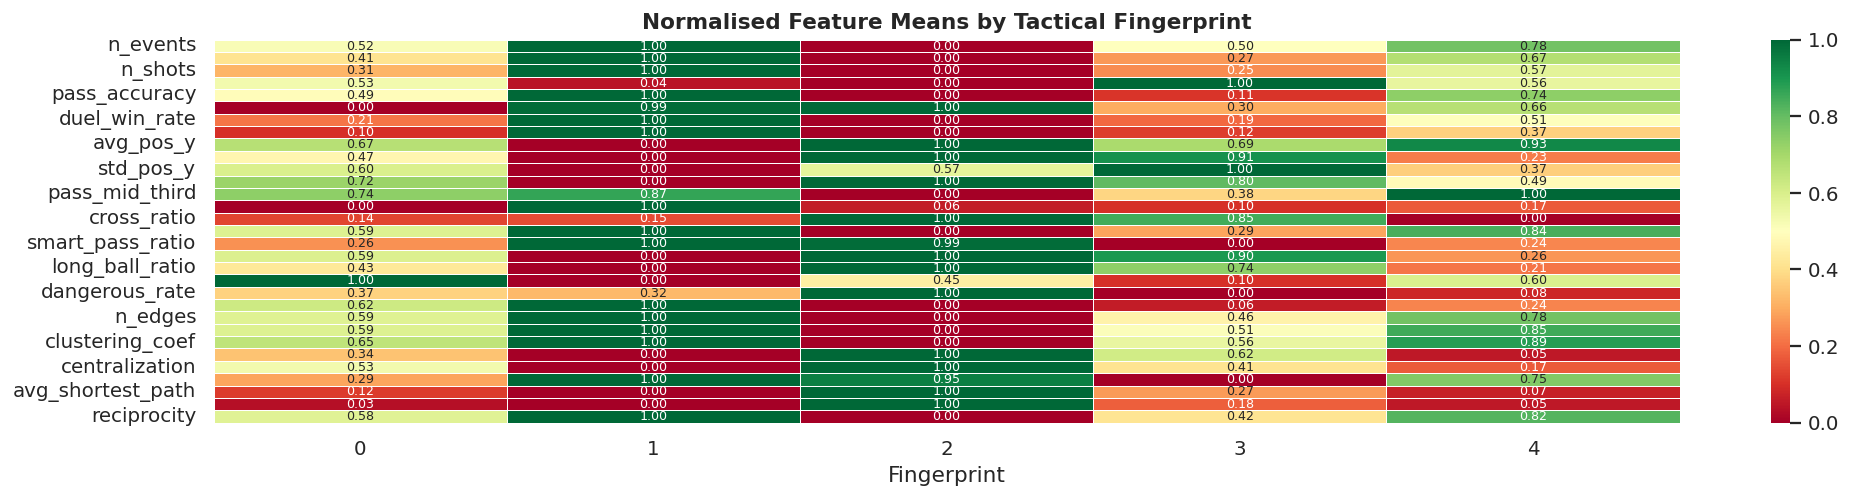

In [49]:
# ── Feature means per fingerprint — heatmap ───────────────────────────────────
fp_means = labelled.groupby('fingerprint')[feature_cols].mean()
fp_norm  = (fp_means - fp_means.min()) / (fp_means.max() - fp_means.min() + 1e-9)

fig, ax = plt.subplots(figsize=(16, max(4, N_CLUSTERS*0.8)))
sns.heatmap(fp_norm.T, cmap='RdYlGn', center=0.5,
            annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=0.3, ax=ax)
ax.set_title('Normalised Feature Means by Tactical Fingerprint',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Fingerprint')
plt.tight_layout()
plt.savefig(OUT / 'fingerprint_feature_heatmap.png', dpi=130)
plt.show()

---
## 10. Cross-Competition Analysis

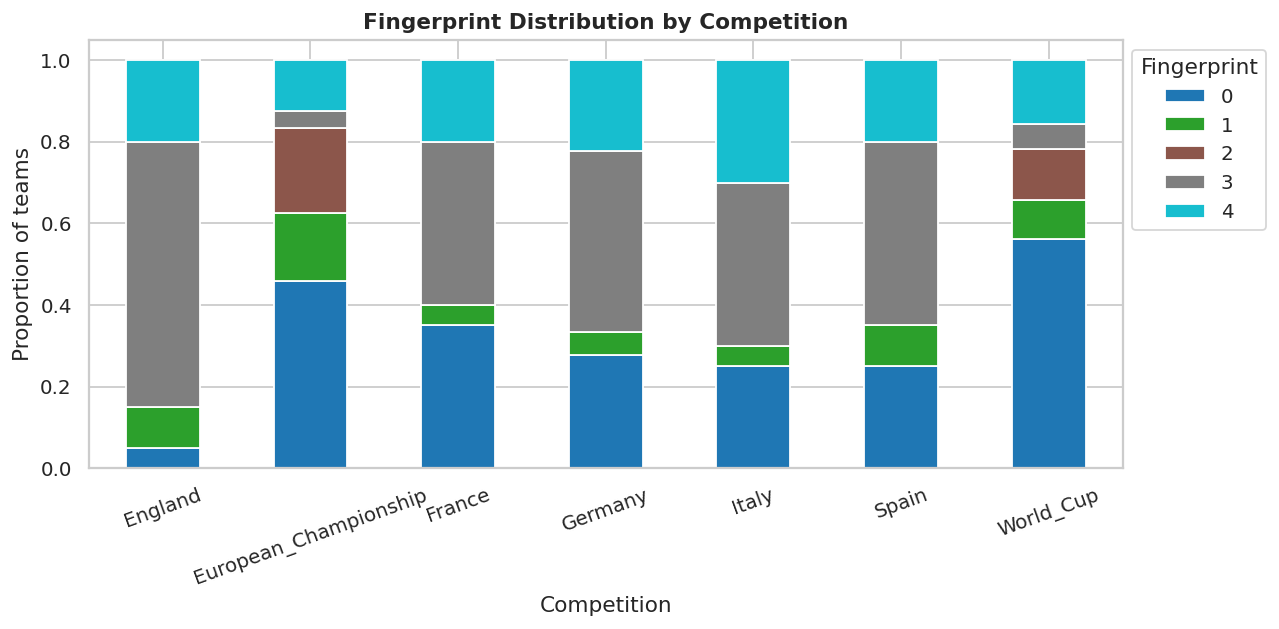

In [50]:
# Fingerprint distribution per competition
fp_comp = labelled.groupby(['competition','fingerprint']).size().unstack(fill_value=0)
fp_comp_pct = fp_comp.div(fp_comp.sum(axis=1), axis=0)

fp_comp_pct.plot.bar(stacked=True, figsize=(10,5), colormap='tab10')
plt.title('Fingerprint Distribution by Competition', fontsize=12, fontweight='bold')
plt.xlabel('Competition'); plt.ylabel('Proportion of teams')
plt.xticks(rotation=20); plt.legend(title='Fingerprint', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig(OUT / 'fingerprint_by_competition.png', dpi=130)
plt.show()

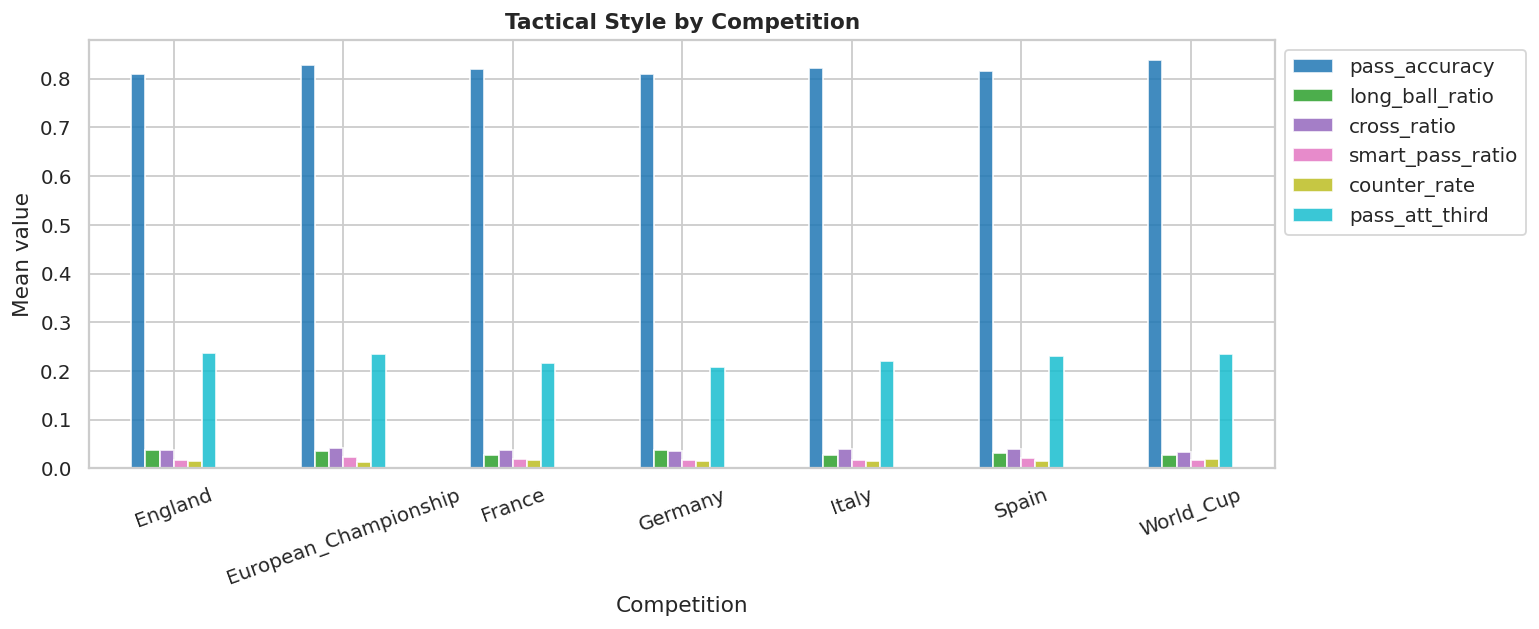

In [51]:
# Tactical style comparison across competitions
style_cols = ['pass_accuracy','long_ball_ratio','cross_ratio','smart_pass_ratio',
              'counter_rate','pass_att_third']
comp_style = labelled.groupby('competition')[style_cols].mean()

fig, ax = plt.subplots(figsize=(12, 5))
comp_style.plot.bar(ax=ax, colormap='tab10', alpha=0.85)
ax.set_title('Tactical Style by Competition', fontsize=12, fontweight='bold')
ax.set_xlabel('Competition'); ax.set_ylabel('Mean value')
ax.legend(bbox_to_anchor=(1,1))
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUT / 'style_by_competition.png', dpi=130)
plt.show()

---
## 11. Summary Table & Save

In [56]:
new_columns = {}
for col in labelled.columns:
    if col.endswith('_y'):
        new_columns[col] = col[:-2] # Remove the last two characters '_y'
labelled = labelled.rename(columns=new_columns)
labelled.head()

,teamId,competition,n_events,n_passes,n_shots,n_duels,pass_accuracy,shot_accuracy,duel_win_rate,avg_pos_x,...,goalsFor,goalsAgainst,name_x,win_rate,points_per_match,goalDiff,fingerprint,embed_x,embed,name
0,674,Spain,810.210526,413.789474,11.000000,224.631579,0.835443,0.391434,0.394563,48.026460,...,1.710526,1.000000,Valencia,0.578947,1.921053,0.710526,0,7.368587,6.113252,Valencia
1,675,Spain,947.500000,581.078947,16.605263,206.842105,0.879185,0.421921,0.427308,52.202797,...,2.473684,1.157895,Real Madrid,0.578947,2.000000,1.315789,1,9.680804,8.118134,Real Madrid
2,676,Spain,968.157895,612.105263,13.210526,202.789474,0.883462,0.485128,0.428679,51.206289,...,2.605263,0.763158,Barcelona,0.736842,2.447368,1.842105,1,9.879944,7.832149,Barcelona
3,677,Spain,797.815789,382.605263,10.657895,221.421053,0.799323,0.333401,0.386356,48.622159,...,1.000000,2.000000,Deportivo La Coru\u00f1a,0.157895,0.763158,-1.000000,3,5.140182,4.488888,Deportivo La Coru\u00f1a
4,678,Spain,803.842105,395.315789,9.921053,229.631579,0.799027,0.379532,0.393521,49.712476,...,1.078947,1.289474,Athletic Club,0.263158,1.131579,-0.210526,0,5.277513,5.264870,Athletic Club


In [57]:
summary = labelled.groupby('fingerprint').agg(
    n_teams            = ('teamId', 'nunique'),
    win_rate           = ('win_rate', 'mean'),
    points_per_match   = ('points_per_match', 'mean'),
    goal_diff          = ('goalDiff', 'mean'),
    pass_accuracy      = ('pass_accuracy', 'mean'),
    long_ball_ratio    = ('long_ball_ratio', 'mean'),
    cross_ratio        = ('cross_ratio', 'mean'),
    smart_pass_ratio   = ('smart_pass_ratio', 'mean'),
    counter_rate       = ('counter_rate', 'mean'),
    density            = ('density', 'mean'),
    centralization     = ('centralization', 'mean'),
    clustering_coef    = ('clustering_coef', 'mean'),
).round(3)

print('\n── Tactical Fingerprint Summary ──')
display(summary)


── Tactical Fingerprint Summary ──


,n_teams,win_rate,points_per_match,goal_diff,pass_accuracy,long_ball_ratio,cross_ratio,smart_pass_ratio,counter_rate,density,centralization,clustering_coef
fingerprint,,,,,,,,,,,,
0,50,0.347,1.261,-0.141,0.828,0.029,0.035,0.018,0.018,0.610,0.540,0.837
1,12,0.582,1.930,0.955,0.882,0.011,0.035,0.022,0.014,0.681,0.491,0.867
2,8,0.278,1.054,-0.385,0.776,0.054,0.046,0.022,0.015,0.510,0.582,0.782
3,49,0.279,1.076,-0.467,0.788,0.043,0.044,0.017,0.014,0.596,0.529,0.829
4,30,0.467,1.626,0.304,0.854,0.020,0.033,0.018,0.016,0.655,0.507,0.857


In [59]:
# Teams per fingerprint
for fp_id, grp in labelled.groupby('fingerprint'):
    teams_list = ', '.join(sorted(grp['name'].dropna().unique()))
    print(f'\n── FP {fp_id}  ({len(grp)} teams) ──')
    print(teams_list)


── FP 0  (52 teams) ──
Athletic Club, Atl\u00e9tico Madrid, Australia, Austria, Benevento, Bologna, Bordeaux, Colombia, Costa Rica, Croatia, Denmark, Egypt, Fiorentina, France, Guingamp, Hertha BSC, Hoffenheim, Hungary, Italy, Japan, Korea Republic, Lazio, Metz, Mexico, Monaco, Montpellier, Morocco, Nigeria, Panama, Peru, Poland, Portugal, Rennes, Romania, Saint-\u00c9tienne, Schalke 04, Sevilla, Slovakia, Southampton, Sweden, Switzerland, Torino, Tunisia, Turkey, Uruguay, Valencia, Villarreal, Wales, Werder Bremen, Wolfsburg

── FP 1  (14 teams) ──
Arsenal, Barcelona, Bayern M\u00fcnchen, Belgium, Brazil, England, Germany, Manchester City, Napoli, PSG, Real Madrid, Spain

── FP 2  (9 teams) ──
Albania, Czech Republic, Iceland, Iran, Northern Ireland, Republic of Ireland, Senegal, Sweden

── FP 3  (49 teams) ──
AFC Bournemouth, Amiens SC, Angers, Augsburg, Brighton & Hove Albion, Burnley, Caen, Cagliari, Chievo, Crotone, Crystal Palace, Deportivo Alav\u00e9s, Deportivo La Coru\u00f1a,

In [60]:
# Save everything to Drive
labelled.to_csv(OUT / 'fingerprints.csv', index=False)
labelled.to_parquet(OUT / 'fingerprints.parquet', index=False)
summary.to_csv(OUT / 'fingerprint_summary.csv')

import pickle
with open(OUT / 'pipeline_artifacts.pkl', 'wb') as f:
    pickle.dump({'scaler': result['scaler'], 'pca': result['pca']}, f)

print(f'\nAll results saved to {DRIVE_OUT}')
print('Files written:')
for p in sorted(OUT.glob('*')):
    print(f'  {p.name}  ({p.stat().st_size/1024:.0f} KB)')


All results saved to /content/drive/MyDrive/Football_Events_SDS/Results
Files written:
  cluster_quality.png  (67 KB)
  eda_event_distribution.png  (67 KB)
  eda_match_outcomes.png  (57 KB)
  eda_pass_accuracy.png  (47 KB)
  eda_player_roles.png  (21 KB)
  eda_spatial_heatmap.png  (58 KB)
  feature_correlation.png  (220 KB)
  feature_vs_win_rate.png  (208 KB)
  fingerprint_by_competition.png  (59 KB)
  fingerprint_feature_heatmap.png  (135 KB)
  fingerprint_radar.png  (203 KB)
  fingerprint_scatter.png  (194 KB)
  fingerprint_summary.csv  (1 KB)
  fingerprints.csv  (118 KB)
  fingerprints.parquet  (76 KB)
  goalDiff_y_by_fp.png  (24 KB)
  network_metric_distributions.png  (78 KB)
  pca_loadings.png  (84 KB)
  pca_variance.png  (44 KB)
  pipeline_artifacts.pkl  (5 KB)
  points_per_match_y_by_fp.png  (31 KB)
  sample_passing_network.png  (207 KB)
  style_by_competition.png  (71 KB)
  win_rate_y_by_fp.png  (26 KB)


---
## 12. Additional Cluster Diagnostics

In [ ]:
# ── Silhouette score vs k (Ward / PCA-10) ────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

fp_df = pd.read_csv(OUT / 'fingerprints.csv')

_exclude = {
    'teamId', 'competition',
    'win_rate_profiles', 'draw', 'loss',
    'points_per_match_profiles', 'goalDiff_profiles', 'goalsFor', 'goalsAgainst',
    'name_x', 'win_rate', 'points_per_match', 'goalDiff',
    'fingerprint', 'embed_x', 'embed', 'name',
}
_feat_cols = [c for c in fp_df.columns if c not in _exclude]

X_raw_fp = fp_df[_feat_cols].fillna(0).values
X_sc_fp  = StandardScaler().fit_transform(X_raw_fp)
X_pca_fp = PCA(n_components=min(10, len(_feat_cols)), random_state=42).fit_transform(X_sc_fp)

k_vals, sil_vals = list(range(3, 9)), []
for k in k_vals:
    labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_pca_fp)
    sil_vals.append(silhouette_score(X_pca_fp, labels))

chosen_sil = sil_vals[k_vals.index(5)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_vals, sil_vals, 'o-', color='steelblue', linewidth=2, markersize=7)
ax.scatter([5], [chosen_sil], s=150, color='crimson', zorder=5,
           label=f'k = 5 (chosen,  s = {chosen_sil:.3f})')
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score vs Number of Clusters\n'
             '(Agglomerative / Ward linkage, PCA-10)', fontsize=13)
ax.set_xticks(k_vals)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'silhouette_scores.png', dpi=130)
plt.show()

print('Silhouette scores (Ward / PCA-10):')
for k, s in zip(k_vals, sil_vals):
    marker = '  <- chosen' if k == 5 else ''
    print(f'  k = {k}:  {s:.4f}{marker}')


In [ ]:
# ── Kruskal-Wallis test — fingerprint outcome differences ─────────────────────
import pandas as pd
from scipy.stats import kruskal

fp_df = pd.read_csv(OUT / 'fingerprints.csv')

kw_rows = []
print(f'{"Metric":<25}  {"H-statistic":>12}  {"p-value":>12}  Sig.')
print('-' * 60)
for metric in ['win_rate', 'points_per_match', 'goalDiff']:
    groups = [grp[metric].dropna().values for _, grp in fp_df.groupby('fingerprint')]
    H, p   = kruskal(*groups)
    sig    = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    kw_rows.append({'metric': metric, 'H_statistic': round(H, 4), 'p_value': f'{p:.4e}'})
    print(f'{metric:<25}  {H:>12.4f}  {p:>12.4e}  {sig}')

kw_df = pd.DataFrame(kw_rows)
kw_df.to_csv(OUT / 'kruskal_results.csv', index=False)
print('\nSaved -> kruskal_results.csv')
display(kw_df)


In [ ]:
# ── Outcome box plots by tactical fingerprint ─────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

fp_df = pd.read_csv(OUT / 'fingerprints.csv')

FP_NAMES = {
    0: 'Balanced\nMid-Table',
    1: 'Elite\nPossession',
    2: 'Direct\nLong Ball',
    3: 'Defensive\nDirect',
    4: 'Structured\nAttack',
}

METRICS = [
    ('win_rate',         'Win Rate',         '#4C72B0'),
    ('points_per_match', 'Points per Match', '#55A868'),
    ('goalDiff',         'Goal Difference',  '#C44E52'),
]

fps_sorted   = sorted(fp_df['fingerprint'].unique())
xtick_labels = [f'FP{fp}\n{FP_NAMES[fp]}' for fp in fps_sorted]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (col, label, color) in zip(axes, METRICS):
    groups = [fp_df[fp_df['fingerprint'] == fp][col].dropna().values for fp in fps_sorted]
    bp = ax.boxplot(groups, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    ax.set_xticks(range(1, len(fps_sorted) + 1))
    ax.set_xticklabels(xtick_labels, fontsize=9)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylabel(label, fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Match Outcomes by Tactical Fingerprint', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT / 'outcome_by_fingerprint.png', dpi=130, bbox_inches='tight')
plt.show()


In [ ]:
# ── Ward-linkage dendrogram with k=5 cut line ────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

fp_df = pd.read_csv(OUT / 'fingerprints.csv')

_exclude = {
    'teamId', 'competition',
    'win_rate_profiles', 'draw', 'loss',
    'points_per_match_profiles', 'goalDiff_profiles', 'goalsFor', 'goalsAgainst',
    'name_x', 'win_rate', 'points_per_match', 'goalDiff',
    'fingerprint', 'embed_x', 'embed', 'name',
}
_feat_cols = [c for c in fp_df.columns if c not in _exclude]

X_raw_fp = fp_df[_feat_cols].fillna(0).values
X_sc_fp  = StandardScaler().fit_transform(X_raw_fp)
X_pca_fp = PCA(n_components=min(10, len(_feat_cols)), random_state=42).fit_transform(X_sc_fp)

Z = linkage(X_pca_fp, method='ward')

# Height midway between the 5→4 and 6→5 merge steps gives exactly 5 clusters
cut_height = 0.5 * (Z[-4, 2] + Z[-5, 2])

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, no_labels=True, color_threshold=cut_height,
           above_threshold_color='grey')
ax.axhline(y=cut_height, color='crimson', linestyle='--', linewidth=1.8,
           label=f'k = 5 cut  (height ≈ {cut_height:.1f})')
ax.set_title('Ward-Linkage Dendrogram — Tactical Fingerprints', fontsize=13)
ax.set_xlabel('Team-Season Observations', fontsize=11)
ax.set_ylabel('Linkage Distance (Ward)', fontsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(OUT / 'dendrogram.png', dpi=130)
plt.show()
